In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Input, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

In [ ]:
# Path to the data folder containing train and test folders

data_folder ='/kaggle/input/statefarmddd'
# Load the images and labels into lists
images = []
labels = []
folders = os.listdir(data_folder)
class_names = os.listdir(os.path.join(data_folder,folders[-1]))
#class_names.remove('.DS_Store')

print(class_names)

for folder in folders:
    folder_path = os.path.join(data_folder, folder)
    for class_index, class_name in enumerate(class_names):
        class_folder_path = os.path.join(folder_path, class_name)
        print(class_folder_path)
        if class_folder_path.find(".DS") != -1:
          continue
        for filename in os.listdir(class_folder_path):
            if filename.endswith('.jpg'):
                img = load_img(os.path.join(class_folder_path, filename), target_size=(224, 224))
                img_arr = img_to_array(img)
                images.append(img_arr)
                labels.append(class_index)

['c6_Drinking', 'c0_NotDistracted', 'c1_TextingRightHand', 'c7_ReachingBackSeat', 'c2_CallingRightHand']
/kaggle/input/statefarmddd/StateFarmDDD/c6_Drinking
/kaggle/input/statefarmddd/StateFarmDDD/c0_NotDistracted
/kaggle/input/statefarmddd/StateFarmDDD/c1_TextingRightHand
/kaggle/input/statefarmddd/StateFarmDDD/c7_ReachingBackSeat
/kaggle/input/statefarmddd/StateFarmDDD/c2_CallingRightHand


In [ ]:
# Convert the lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=4)

# Scale the pixel values to a range between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_test.shape[0]

853

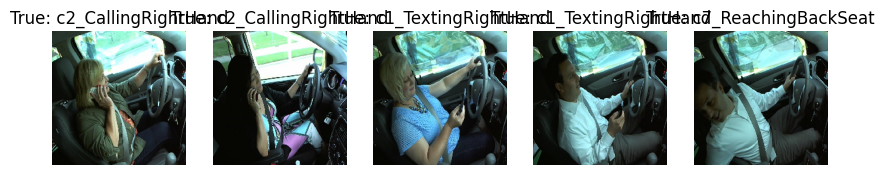

In [ ]:
# Display sample images at the beginning
sample_images = X_test[:5]  # Change the number to display more or fewer images
sample_labels = y_test[:5]

plt.figure(figsize=(10, 5))
for i in range(len(sample_images)):
    plt.subplot(1, len(sample_images), i + 1)
    plt.imshow(sample_images[i].reshape(224, 224, 3))
    plt.title(f'True: {class_names[sample_labels[i]]}')
    plt.axis('off')
plt.show()

In [ ]:
#to encode labels into numerics
def convert(array):
  encoded = []
  for i in array:
    column  =[0] * len(class_names)
    column[i] = 1
    encoded.append(column)
  return np.array(encoded)

y_train = convert(y_train)
y_test = convert(y_test)

In [ ]:
X_train.shape, y_train.shape , X_test.shape, y_test.shape

((3409, 224, 224, 3), (3409, 5), (853, 224, 224, 3), (853, 5))

In [ ]:
y_train[1]

array([0, 0, 0, 0, 1])

In [ ]:
# Build the Sequential CNN model-1
model = Sequential()
inputshape = X_train.shape[1:]
#model.add(Input(shape = X_train.shape[1:],))

model.add(Conv2D(10, kernel_size=(3,3), strides=(1,1), padding='valid', activation=tf.keras.layers.LeakyReLU(alpha=0.01), input_shape=inputshape))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(20, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(5, activation='softmax'))  # Use softmax activation for multi-class classification

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-15 09:24:07.663771: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 20)   │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 58320)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     5,832,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,834,705 (22.26 MB)

 Trainable params: 5,834,705 (22.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, batch_size=16, epochs=25, validation_data=(X_test, y_test))


Epoch 1/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 64s 287ms/step - accuracy: 0.5961 - loss: 1.4457 - val_accuracy: 0.9789 - val_loss: 0.0857
Epoch 2/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 60s 280ms/step - accuracy: 0.9842 - loss: 0.0595 - val_accuracy: 0.9930 - val_loss: 0.0400
Epoch 3/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 276ms/step - accuracy: 0.9973 - loss: 0.0143 - val_accuracy: 0.9894 - val_loss: 0.0511
Epoch 4/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 84s 286ms/step - accuracy: 0.9974 - loss: 0.0101 - val_accuracy: 0.9766 - val_loss: 0.0731
Epoch 5/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 274ms/step - accuracy: 0.9940 - loss: 0.0234 - val_accuracy: 0.9918 - val_loss: 0.0320
Epoch 6/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 63s 295ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9965 - val_loss: 0.0212
Epoch 7/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 275ms/step - accuracy: 1.0000 - loss: 9.7836e-05 - val_accuracy: 0.9965 - val_loss: 0.0223
Epoch 8/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 58s 271ms/step - accuracy: 1.0000 - los

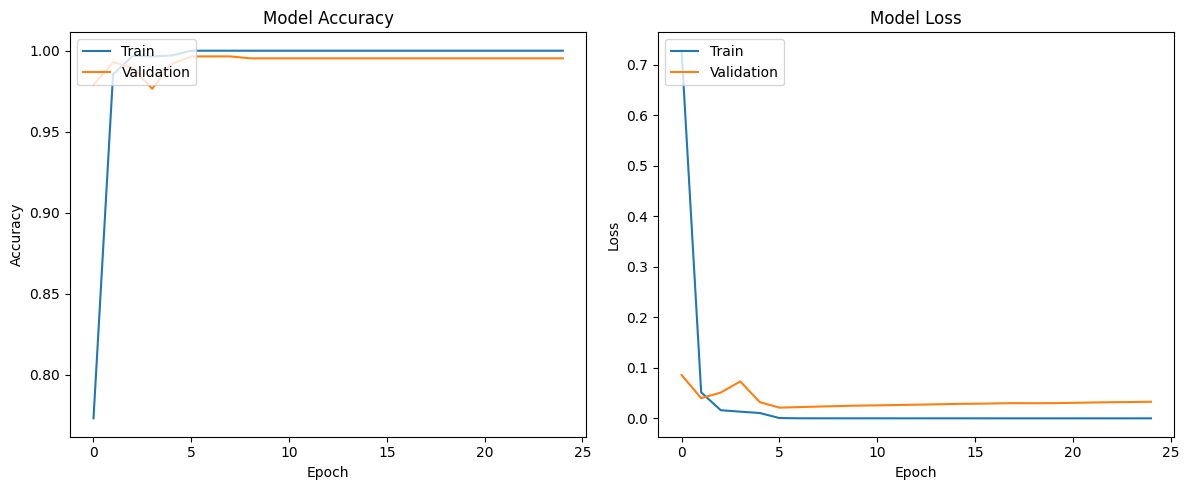

In [ ]:
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

In [ ]:
# Calculating only Test Set Accuracy of the Model
loss, accuracy = model.evaluate(X_test, y_test)

#print(%.3f"Accuracy : {accuracy}")
print('Accuracy : %.3f' % accuracy)

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis =1)
New_y_test = np.argmax(y_test, axis =1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.9952 - loss: 0.0288
Accuracy : 0.995
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step


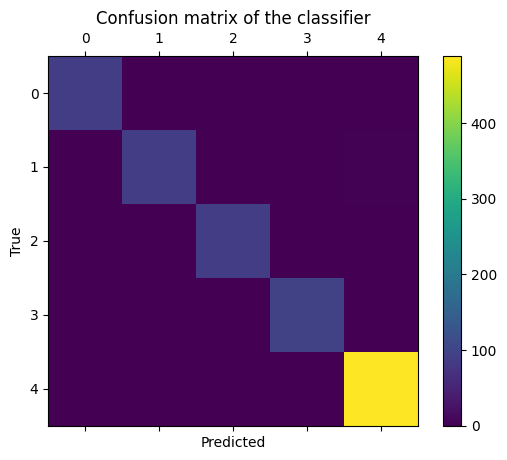

Accuracy :0.9953
0.9947 0.9931 0.9939


In [ ]:
"""""""""""""  STEP 4. CALCULATE Model's PERFORMANCE """""""""""""""
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

cm = confusion_matrix(New_y_test, y_pred)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix of the classifier')
fig.colorbar(cax)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("Accuracy :" + str(round(accuracy_score(New_y_test, y_pred),4)))
p, r, f, s = precision_recall_fscore_support(New_y_test, y_pred, average='macro')
print(round(p,4),round(r,4),round(f,4))

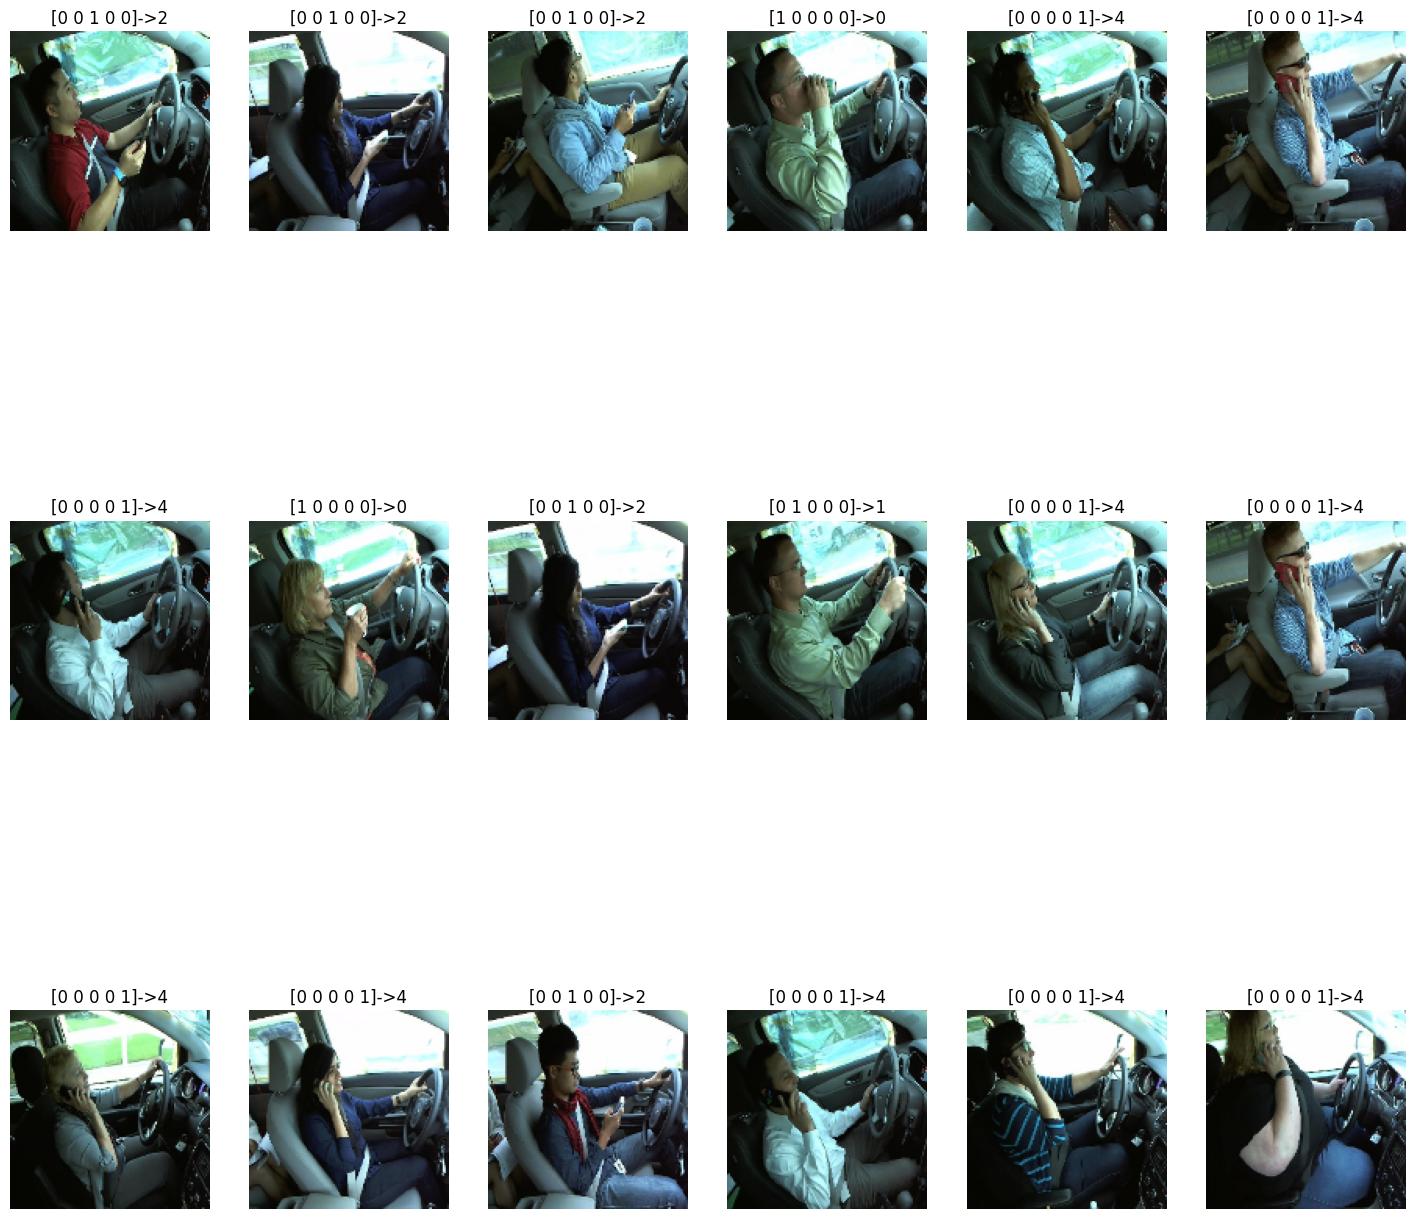

In [ ]:
#Visualising the Dataset Samples
import cv2

plt.figure(figsize=(18, 18))
for i in range(18):
  plt.subplot(3, 6, i + 1)
  fignum = np.random.randint(1, high=125)
  plt.imshow(cv2.resize(X_test[fignum], (128, 128)))
  strname = str(y_test[fignum])+"->"+str(y_pred[fignum])
  plt.title(strname)
  plt.axis("off")